# Практическая работа 2: Кластеризация студентов

## Анализ данных опроса с использованием методов машинного обучения

**Выполнил:** Адаменко Семён Сергеевич, ИВТ 2.1

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr 


import umap


from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score


--- 

## 1. Понимание бизнес-задачи (Business Understanding)

--- 

## 2. Понимание данных (Data Understanding)

In [39]:

try:
    df = pd.read_excel('dlia studentov.xlsx')
    print("Данные успешно загружены.")
except FileNotFoundError:
    print("Ошибка: Файл 'dlia studentov.xlsx' не найден. Убедитесь, что он находится в той же директории.")
    df = pd.DataFrame() 
except Exception as e:
    print(f"Произошла ошибка при загрузке файла: {e}")
    df = pd.DataFrame()

Данные успешно загружены.


### Первичный осмотр данных

In [40]:
if not df.empty:
    print("\nРазмерность набора данных (строки, столбцы):", df.shape)
    print("\nПервые 5 строк данных:\n", df.head())
    print("\nИнформация о типах данных:\n")
    df.info()
    print("\nПропущенные значения в каждом столбце:\n", df.isnull().sum())
else:
    print("Данные не загружены. Пропустим первичный осмотр.")


Размерность набора данных (строки, столбцы): (711, 23)

Первые 5 строк данных:
            ID       Время создания  \
0  1408291245  2023-06-07 20:41:17   
1  1405883214  2023-06-05 09:02:21   
2  1405869646  2023-06-05 08:44:38   
3  1405856131  2023-06-05 08:26:39   
4  1405854542  2023-06-05 08:24:47   

  На каком факультете/в каком институте Вы обучаетесь?  \
0                 институт истории и социальных наук     
1                                институт педагогики     
2                                институт педагогики     
3                                институт педагогики     
4                                институт педагогики     

  Какая платформа для обучения дисциплине "ИНФОКОММУНИКАЦИОННЫЕ ТЕХНОЛОГИИ" использовалась?  \
0                                             Moodle                                          
1                                             Moodle                                          
2                                             Moodle    

### Исследовательский анализ данных (EDA)

Для удобства работы, переименуем столбцы, чтобы они были короче и без специальных символов. Это облегчит доступ и читаемость кода.

In [41]:
if not df.empty:
    new_column_names = {
        'ID': 'ID',
        'Время создания': 'Timestamp',
        'На каком факультете/в каком институте Вы обучаетесь?': 'Faculty',
        'Какая платформа для обучения дисциплине "ИНФОКОММУНИКАЦИОННЫЕ ТЕХНОЛОГИИ" использовалась?': 'Platform_Used',
        'Был ли предусмотрен фидбек (отклик преподавателя на выполненное задание, например, указание ошибок и как их можно исправить)': 'Feedback_Provided',
        'Необходим ли фидбек (отклик преподавателя на выполненное задание, например, указание ошибок и как их можно исправить) в электронном курсе?': 'Feedback_Needed',
        'Был ли автоматический мониторинг присутствия студента на занятии (например, посредством QR-кодов)': 'Monitoring_Provided',
        'Необходим ли автоматический мониторинг присутствия студента на занятии (например, посредством QR-кодов) в электронном курсе?': 'Monitoring_Needed',
        'Материалы, представленные для практического задания, были в разных форматах (например, одновременно и текстовый, и видео)?': 'Materials_Varied_Formats',
        'Необходимо ли представлять материалы для практического задания в разных форматах (например, одновременно и текстовый, и видео)?': 'Materials_Varied_Formats_Needed',
        'Были ли для каждого Практического задания разработаны и опубликованы критерии оценивания?': 'Grading_Criteria_Provided',
        'Необходимы ли для каждого Практического задания критерии оценивания?': 'Grading_Criteria_Needed',
        'Был ли встроенный электронный журнал прогресса выполненных работ студентом?': 'Progress_Journal_Provided',
        'Необходим ли встроенный электронный журнал прогресса выполненных работ студентом?': 'Progress_Journal_Needed',
        'Были ли встроенны в электронный курс видеолекции?': 'Video_Lectures_Provided',
        'Необходимо ли встраивать в электронный курс видеолекции?': 'Video_Lectures_Needed',
        'Были ли встроенные в электронный курс тесты по материалом видео лекций?': 'Tests_Video_Lectures_Provided',
        'Была ли предусмотрена рефлексия (отзыв) после выполнения каждого практического задания?': 'Reflection_Task_Provided',
        'Необходима ли рефлексия (отзыв) после выполнения каждого практического задания?': 'Reflection_Task_Needed',
        'Была ли предусмотрена рефлексия (отзыв) после завершения работы по дисциплине?': 'Reflection_Discipline_Provided',
        'Необходима ли рефлексия (отзыв) после завершения работы по дисциплине?': 'Reflection_Discipline_Needed',
        'Было ли организовано взаимодействие с преподавателями посредством мессенджеров?': 'Messenger_Interaction_Provided',
        'Необходимо ли организовывать взаимодействие с преподавателями посредством мессенджеров?': 'Messenger_Interaction_Needed'
    }
    df.rename(columns=new_column_names, inplace=True)
    print("\nКолонки переименованы.\n")
    print(df.head())
else:
    print("Данные не загружены. Пропустим переименование колонок.")


Колонки переименованы.

           ID            Timestamp                             Faculty  \
0  1408291245  2023-06-07 20:41:17  институт истории и социальных наук   
1  1405883214  2023-06-05 09:02:21                 институт педагогики   
2  1405869646  2023-06-05 08:44:38                 институт педагогики   
3  1405856131  2023-06-05 08:26:39                 институт педагогики   
4  1405854542  2023-06-05 08:24:47                 институт педагогики   

  Platform_Used Feedback_Provided Feedback_Needed Monitoring_Provided  \
0        Moodle               нет             нет                 нет   
1        Moodle                да              да                 нет   
2        Moodle                да              да                  да   
3        Moodle                да              да                 нет   
4        Moodle                да              да                 нет   

  Monitoring_Needed Materials_Varied_Formats Materials_Varied_Formats_Needed  \
0          

### Анализ отдельных признаков


Анализ распределения ответов для бинарных признаков (предпочтения):



/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/ipykernel_72342/4032343461.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/ipykernel_72342/4032343461.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/ipykernel_72342/4032343461.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/

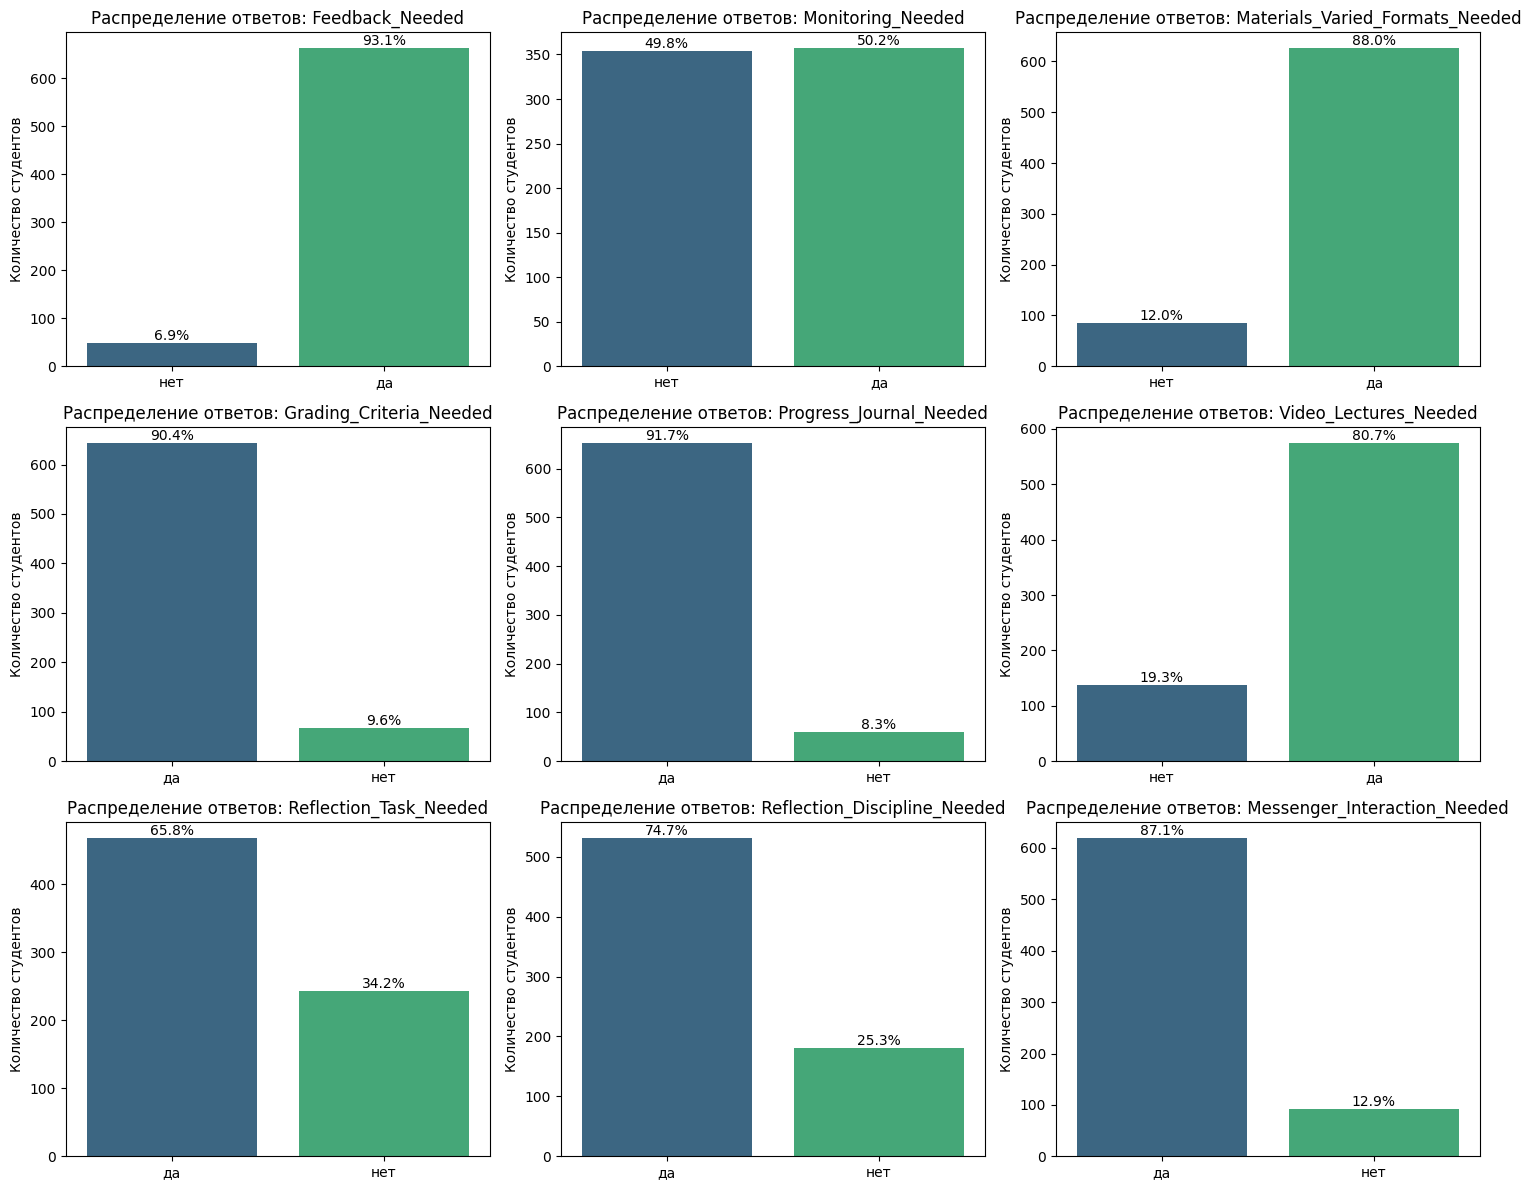


Распределение студентов по факультетам/институтам:



/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/ipykernel_72342/4032343461.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Faculty', data=df, order=df['Faculty'].value_counts().index, palette='crest')


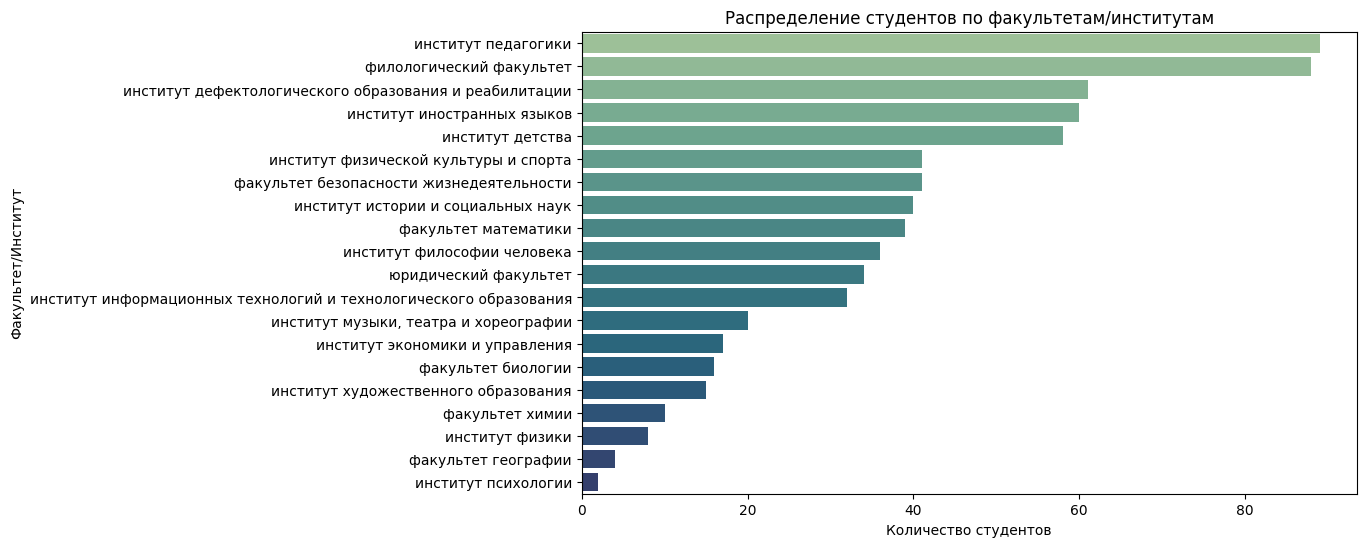

In [42]:
if not df.empty:

    binary_features_for_clustering = [
        'Feedback_Needed',
        'Monitoring_Needed',
        'Materials_Varied_Formats_Needed',
        'Grading_Criteria_Needed',
        'Progress_Journal_Needed',
        'Video_Lectures_Needed',
        'Reflection_Task_Needed',
        'Reflection_Discipline_Needed',
        'Messenger_Interaction_Needed'
    ]

    print("\nАнализ распределения ответов для бинарных признаков (предпочтения):\n")
    plt.figure(figsize=(15, 12))
    for i, col in enumerate(binary_features_for_clustering):
        plt.subplot(3, 3, i + 1) 
        sns.countplot(x=col, data=df, palette='viridis')
        plt.title(f'Распределение ответов: {col}')
        plt.xlabel('') 
        plt.ylabel('Количество студентов')
        total = len(df[col])
        for p in plt.gca().patches:
            height = p.get_height()
            plt.gca().text(p.get_x() + p.get_width()/2., height + 0.1,
                           f'{height / total:.1%}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    print("\nРаспределение студентов по факультетам/институтам:\n")
    plt.figure(figsize=(10, 6))
    sns.countplot(y='Faculty', data=df, order=df['Faculty'].value_counts().index, palette='crest')
    plt.title('Распределение студентов по факультетам/институтам')
    plt.xlabel('Количество студентов')
    plt.ylabel('Факультет/Институт')
    plt.show()

else:
    print("Данные не загружены. Пропустим EDA.")

### Анализ связей между бинарными признаками (Коэффициент Фи)

/var/folders/lf/smxqwm254hj7mlfz1m_6lk400000gp/T/ipykernel_72342/2266357838.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  phi_matrix.loc[col1, col2] = pearsonr(df_encoded_phi[col1], df_encoded_phi[col2])[0]


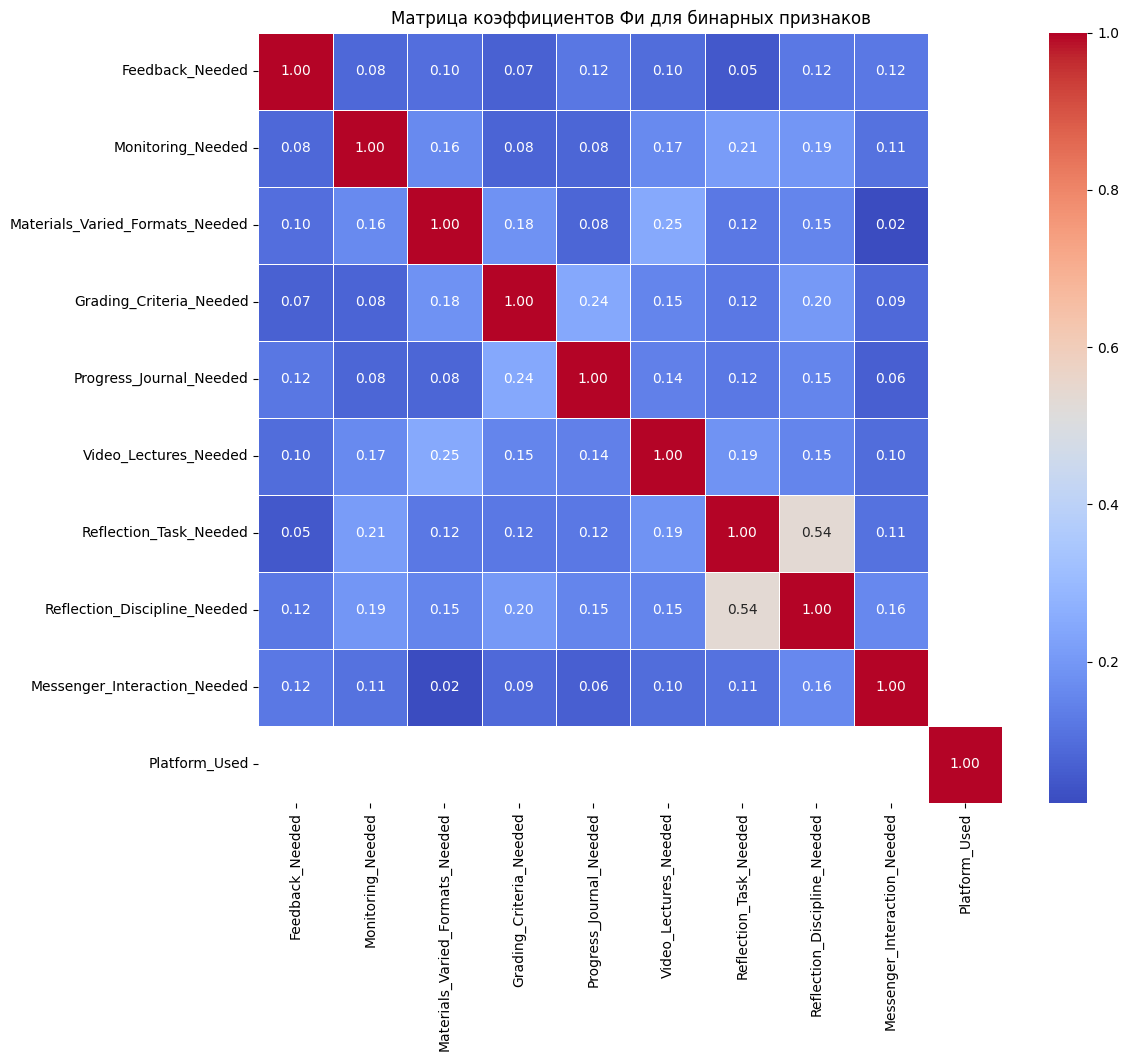

In [43]:
if not df.empty:
    df_encoded_phi = df[binary_features_for_clustering + ['Platform_Used']].copy()

    for col in binary_features_for_clustering:
        df_encoded_phi[col] = df_encoded_phi[col].map({'да': 1, 'нет': 0})

    df_encoded_phi['Platform_Used'] = df_encoded_phi['Platform_Used'].map({'Moodle': 1, 'Авторская платформа': 0})

    df_encoded_phi = df_encoded_phi.apply(pd.to_numeric, errors='coerce')

    df_encoded_phi.dropna(inplace=True)

    phi_matrix = pd.DataFrame(index=df_encoded_phi.columns, columns=df_encoded_phi.columns)

    for col1 in df_encoded_phi.columns:
        for col2 in df_encoded_phi.columns:
            if col1 == col2:
                phi_matrix.loc[col1, col2] = 1.0
            else:
                phi_matrix.loc[col1, col2] = pearsonr(df_encoded_phi[col1], df_encoded_phi[col2])[0]

    plt.figure(figsize=(12, 10))
    sns.heatmap(phi_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Матрица коэффициентов Фи для бинарных признаков')
    plt.show()

else:
    print("Данные не загружены. Пропустим расчет коэффициента Фи.")

### Идентификация целевых признаков для кластеризации

На основе анализа и понимания бизнес-задачи, для кластеризации будут использоваться **бинарные признаки, отражающие *потребности* и *предпочтения* студентов**. Признаки, касающиеся того, что *было* предусмотрено (`_Provided`), не будут использоваться напрямую для кластеризации, так как они описывают текущую ситуацию, а не желания студентов. Также не будут использоваться `ID`, `Timestamp` и `Faculty`.

Список признаков для кластеризации:

* `Feedback_Needed`
* `Monitoring_Needed`
* `Materials_Varied_Formats_Needed`
* `Grading_Criteria_Needed`
* `Progress_Journal_Needed`
* `Video_Lectures_Needed`
* `Reflection_Task_Needed`
* `Reflection_Discipline_Needed`
* `Messenger_Interaction_Needed`

Признак `Faculty` (факультет/институт) будет сохранен для анализа распределения кластеров по факультетам на этапе оценки и визуализации, но не для самой кластеризации.

--- 

## 3. Подготовка данных (Data Preparation)

### Очистка данных и кодирование категориальных признаков

In [44]:
if not df.empty:
    features_for_clustering = [
        'Feedback_Needed',
        'Monitoring_Needed',
        'Materials_Varied_Formats_Needed',
        'Grading_Criteria_Needed',
        'Progress_Journal_Needed',
        'Video_Lectures_Needed',
        'Tests_Video_Lectures_Provided',
        'Reflection_Task_Needed',
        'Reflection_Discipline_Needed',
        'Messenger_Interaction_Needed'
    ]

    df_processed = df[features_for_clustering + ['Faculty']].copy()

    initial_rows = df_processed.shape[0]
    df_processed.dropna(inplace=True)
    rows_after_dropna = df_processed.shape[0]
    print(f"Удалено строк с пропусками: {initial_rows - rows_after_dropna}")

    binary_mapping = {'да': 1, 'нет': 0}
    for col in features_for_clustering:
        df_processed[col] = df_processed[col].map(binary_mapping)

    print("\nПервые 5 строк обработанных данных:\n", df_processed.head())
    print("\nТипы данных после кодирования:\n")
    df_processed.info()

    X_clustering = df_processed[features_for_clustering]
    faculty_info = df_processed['Faculty'] 

    print("\nРазмерность данных для кластеризации:", X_clustering.shape)
else:
    print("Данные не загружены или не обработаны. Пропустим подготовку данных.")

Удалено строк с пропусками: 0

Первые 5 строк обработанных данных:
    Feedback_Needed  Monitoring_Needed  Materials_Varied_Formats_Needed  \
0                0                  0                                0   
1                1                  1                                1   
2                1                  1                                1   
3                1                  0                                1   
4                1                  0                                1   

   Grading_Criteria_Needed  Progress_Journal_Needed  Video_Lectures_Needed  \
0                        1                        1                      0   
1                        1                        1                      1   
2                        1                        1                      1   
3                        1                        1                      1   
4                        0                        1                      1   

   Tests_Video_Lec

### Снижение размерности с использованием UMAP

UMAP - мощный алгоритм для снижения размерности, который хорошо сохраняет как локальную, так и глобальную структуру данных. Это особенно полезно для визуализации и улучшения качества кластеризации в высокоразмерных пространствах.

/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Эксперименты с UMAP:

  UMAP с n_neighbors=5, min_dist=0.0


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


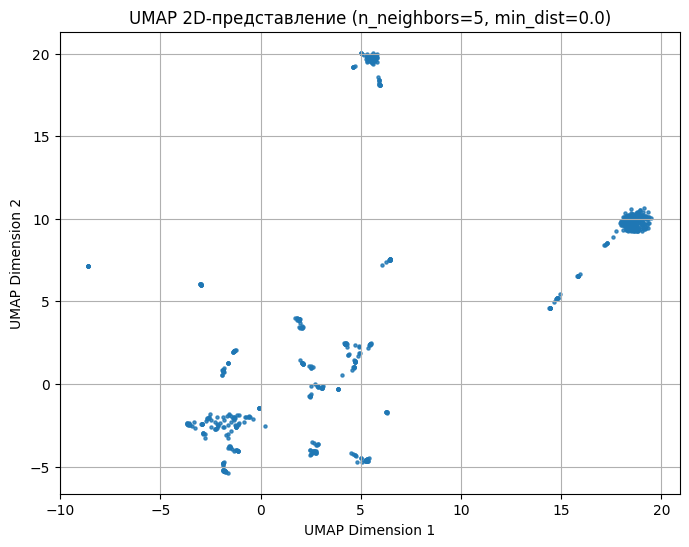

  UMAP с n_neighbors=5, min_dist=0.1


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


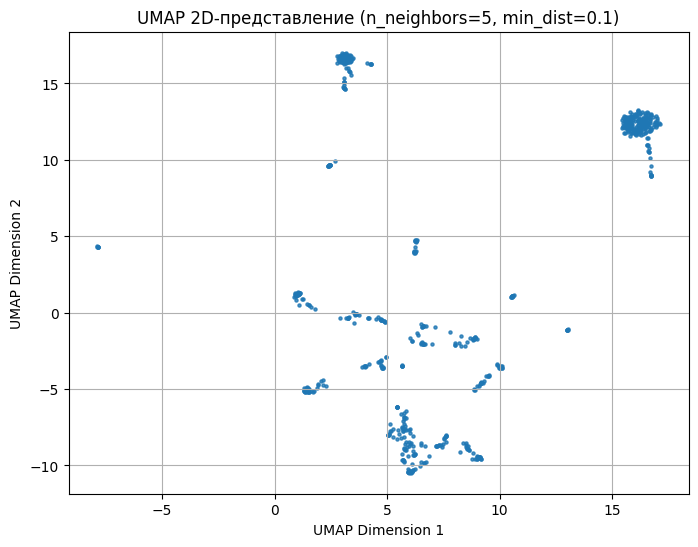

  UMAP с n_neighbors=5, min_dist=0.5


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


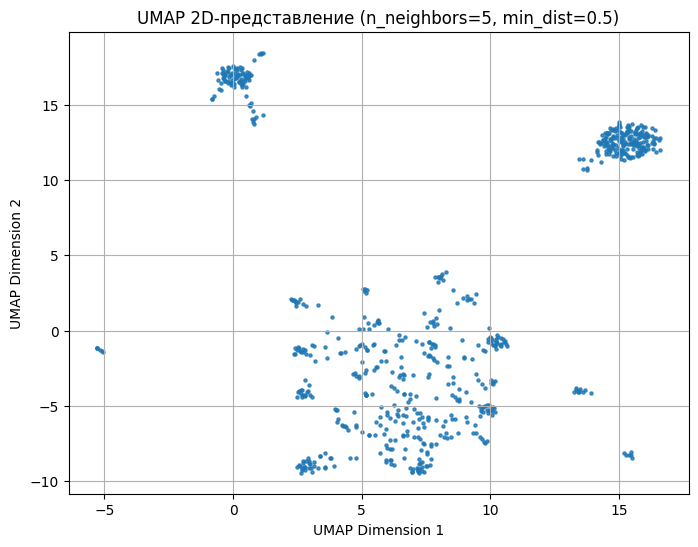

  UMAP с n_neighbors=15, min_dist=0.0


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


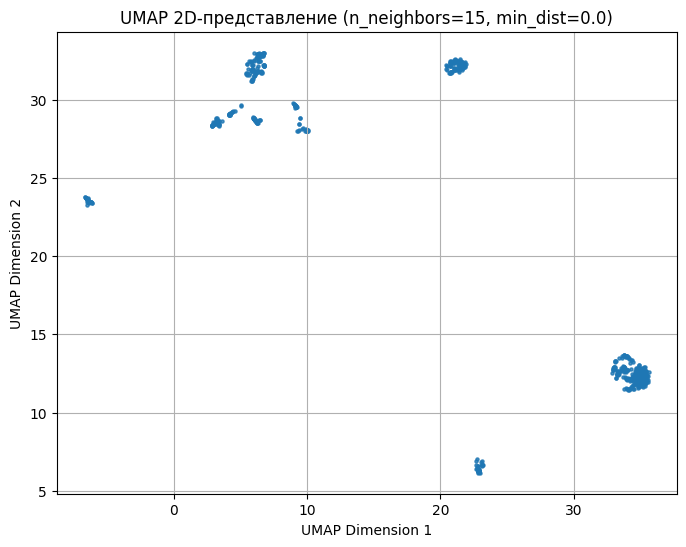

  UMAP с n_neighbors=15, min_dist=0.1


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


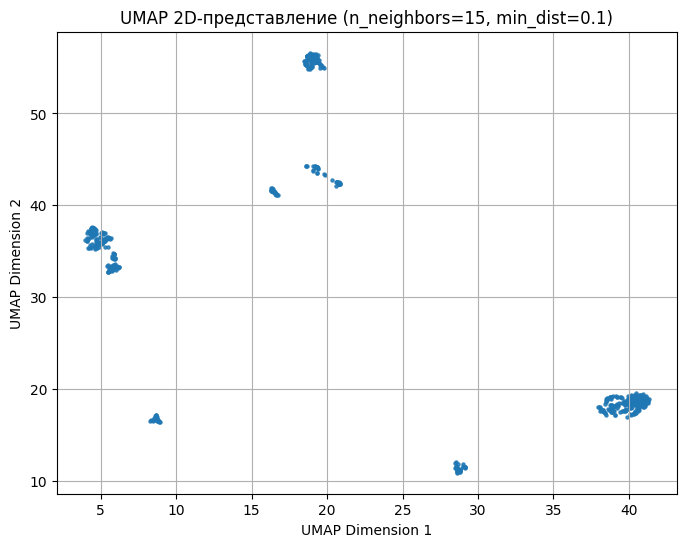

  UMAP с n_neighbors=15, min_dist=0.5


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


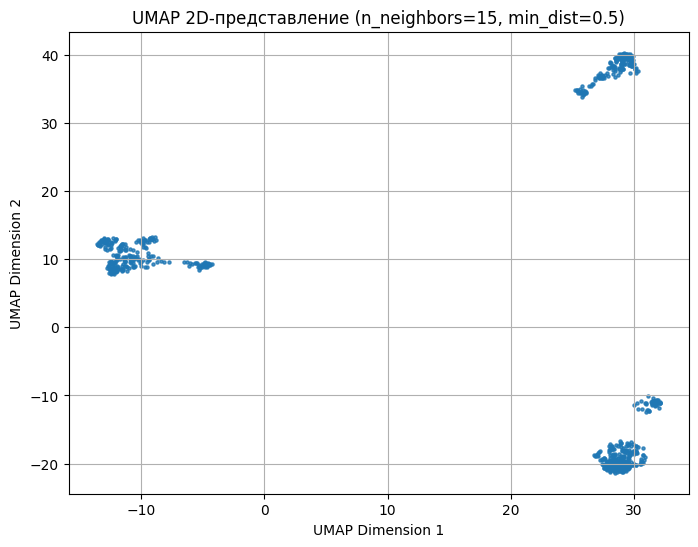

  UMAP с n_neighbors=30, min_dist=0.0


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


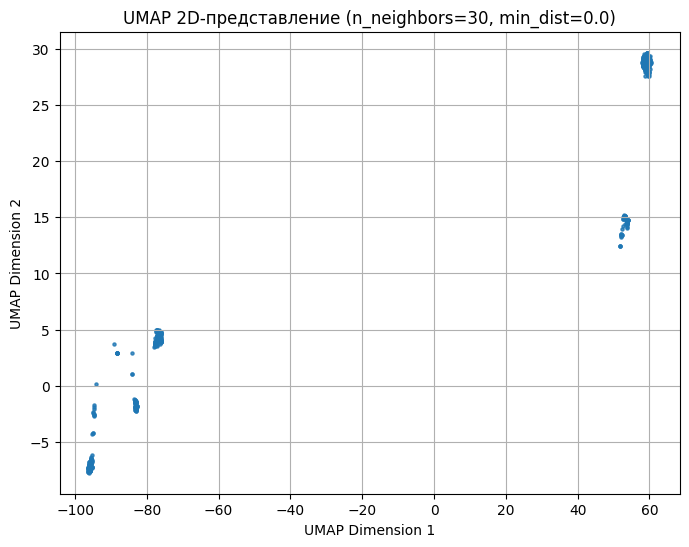

  UMAP с n_neighbors=30, min_dist=0.1


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


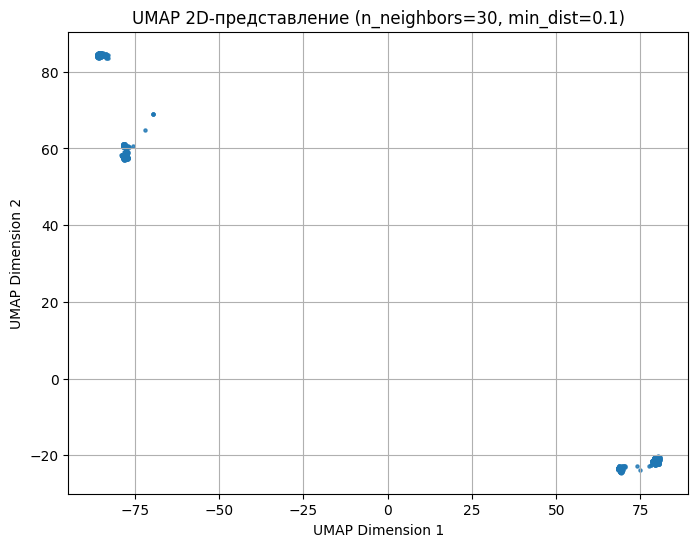

  UMAP с n_neighbors=30, min_dist=0.5


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


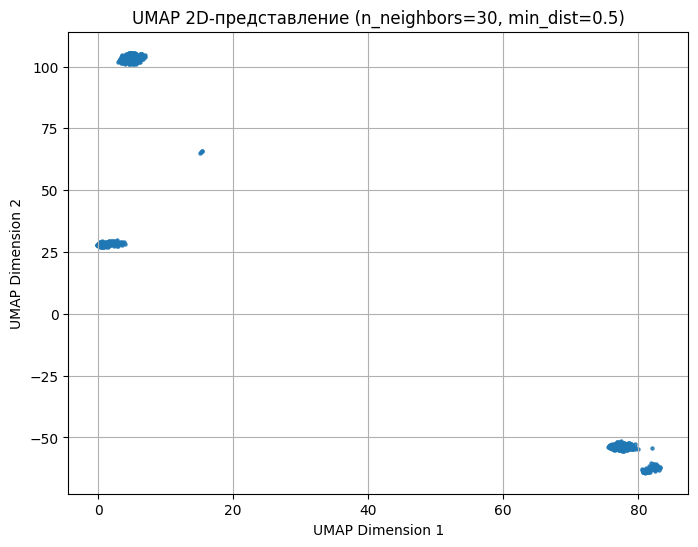


Выводы по подбору гиперпараметров UMAP:

   - Визуально оцените, какие комбинации `n_neighbors` и `min_dist` создают наиболее четкие и разделенные группы точек. Это будет субъективно, но поможет выбрать лучшие параметры для кластеризации.
   - Например, более низкий `min_dist` (ближе к 0) обычно приводит к более компактным кластерам, а `n_neighbors` регулирует баланс между локальной и глобальной структурой.

Окончательное UMAP-преобразование с выбранными параметрами: n_neighbors=15, min_dist=0.1


/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adamenko_ss/Desktop/personal/herzen/venv_myproject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Созданы 2D и 3D UMAP-представления данных.


In [45]:
if 'X_clustering' in locals() and not X_clustering.empty:    
    n_neighbors_values = [5, 15, 30]
    min_dist_values = [0.0, 0.1, 0.5]

    umap_results = {}

    print("\nЭксперименты с UMAP:\n")
    for n_neighbors in n_neighbors_values:
        for min_dist in min_dist_values:
            print(f"  UMAP с n_neighbors={n_neighbors}, min_dist={min_dist}")

            reducer_2d = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42)
            embedding_2d = reducer_2d.fit_transform(X_clustering)
            umap_results[f'2D_n{n_neighbors}_d{min_dist}'] = embedding_2d

            reducer_3d = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=3, random_state=42)
            embedding_3d = reducer_3d.fit_transform(X_clustering)
            umap_results[f'3D_n{n_neighbors}_d{min_dist}'] = embedding_3d

            plt.figure(figsize=(8, 6))
            plt.scatter(embedding_2d[:, 0],
                        embedding_2d[:, 1],
                        s=5, alpha=0.8)
            plt.title(f'UMAP 2D-представление (n_neighbors={n_neighbors}, min_dist={min_dist})')
            plt.xlabel('UMAP Dimension 1')
            plt.ylabel('UMAP Dimension 2')
            plt.grid(True)
            plt.show()

    print("\nВыводы по подбору гиперпараметров UMAP:\n")
    print("   - Визуально оцените, какие комбинации `n_neighbors` и `min_dist` создают наиболее четкие и разделенные группы точек. Это будет субъективно, но поможет выбрать лучшие параметры для кластеризации.")
    print("   - Например, более низкий `min_dist` (ближе к 0) обычно приводит к более компактным кластерам, а `n_neighbors` регулирует баланс между локальной и глобальной структурой.")

    best_n_neighbors = 15
    best_min_dist = 0.1

    print(f"\nОкончательное UMAP-преобразование с выбранными параметрами: n_neighbors={best_n_neighbors}, min_dist={best_min_dist}")
    reducer_2d_final = umap.UMAP(n_neighbors=best_n_neighbors, min_dist=best_min_dist, n_components=2, random_state=42)
    X_umap_2d = reducer_2d_final.fit_transform(X_clustering)

    reducer_3d_final = umap.UMAP(n_neighbors=best_n_neighbors, min_dist=best_min_dist, n_components=3, random_state=42)
    X_umap_3d = reducer_3d_final.fit_transform(X_clustering)

    print("Созданы 2D и 3D UMAP-представления данных.")
else:
    print("Данные для кластеризации не подготовлены. Пропустим снижение размерности UMAP.")

--- 

## 4. Моделирование (Modeling)

На этом этапе мы применим различные алгоритмы кластеризации к исходным (закодированным) данным, а также к 2D и 3D представлениям, полученным с помощью UMAP. Мы также проведем подбор гиперпараметров для каждого алгоритма.


--- Кластеризация на наборе данных: Original_Binary ---
  Обучение KMeans...


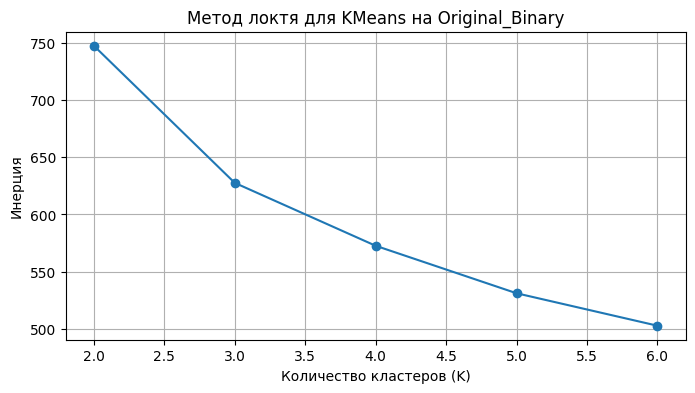

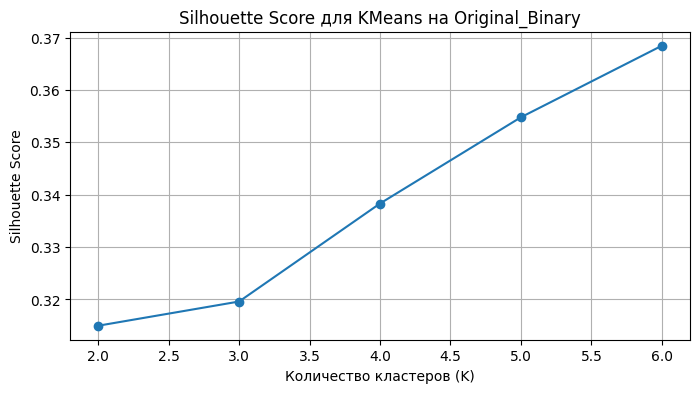

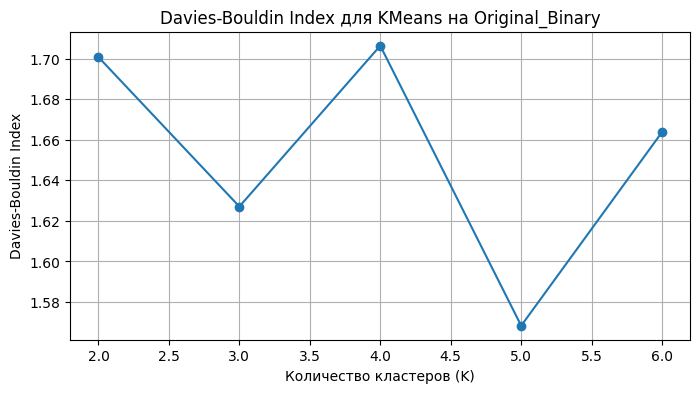

  Кластеризация KMeans завершена. Найдено кластеров: 4
  Обучение AgglomerativeClustering...


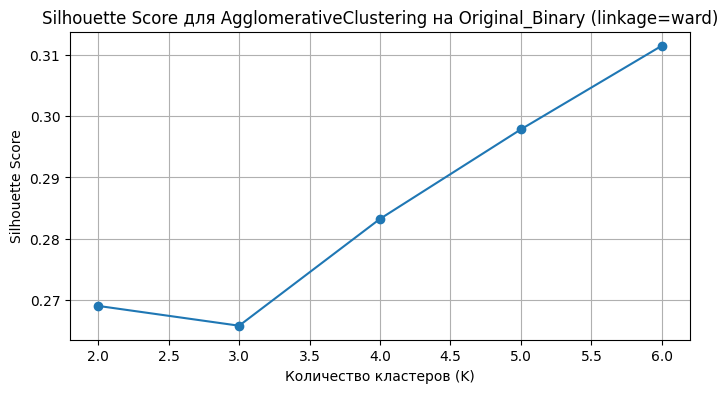

  Кластеризация AgglomerativeClustering завершена. Найдено кластеров: 4
  Обучение DBSCAN...
  DBSCAN сгенерировал 1 кластер или шум (кластер -1). Метрики силуэта/DB не применимы напрямую.
  Количество кластеров (без шума): 27
  Кластеризация DBSCAN завершена. Найдено кластеров: 28
  Обучение GaussianMixture...


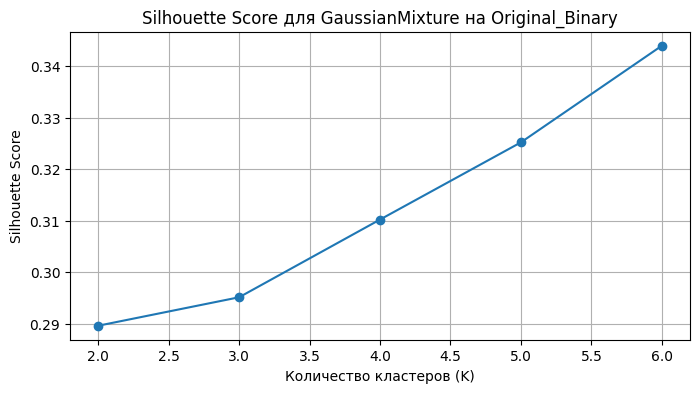

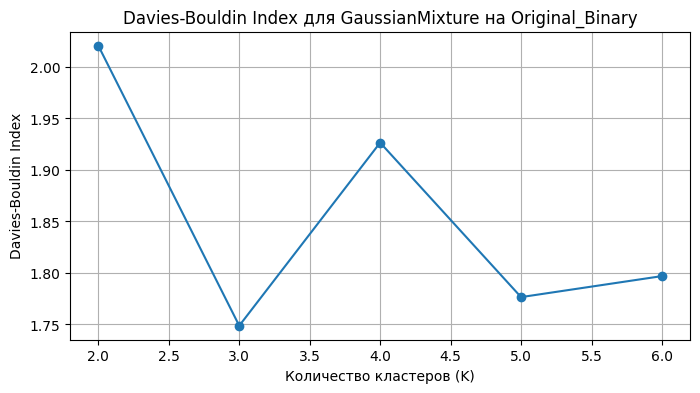

  Кластеризация GaussianMixture завершена. Найдено кластеров: 4

--- Кластеризация на наборе данных: UMAP_2D ---
  Обучение KMeans...


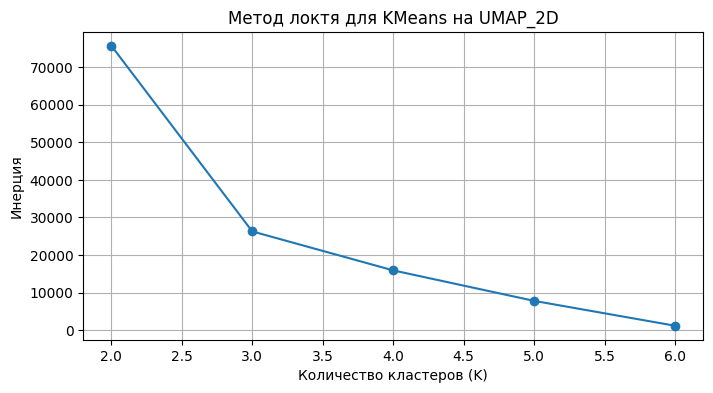

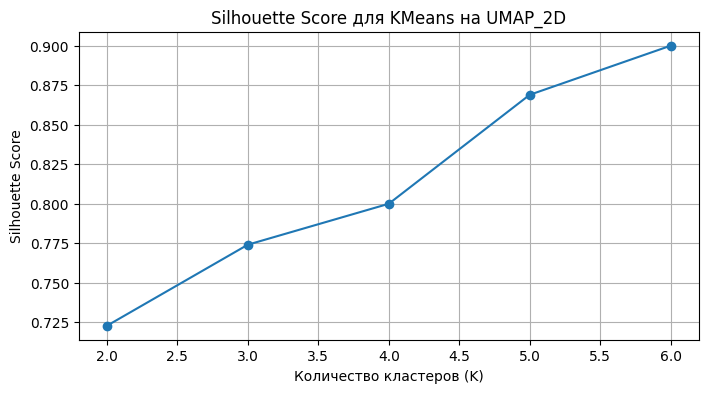

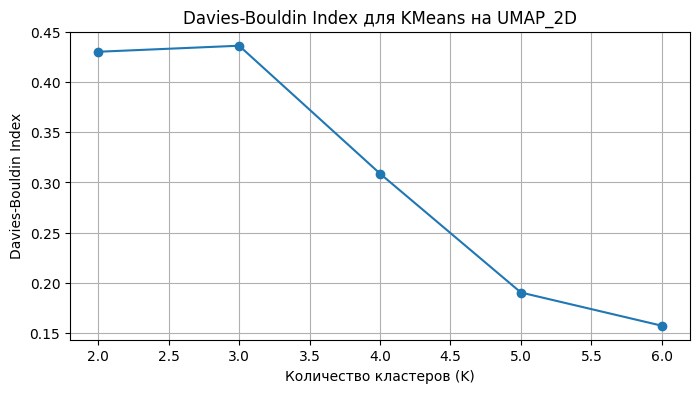

  Кластеризация KMeans завершена. Найдено кластеров: 4
  Обучение AgglomerativeClustering...


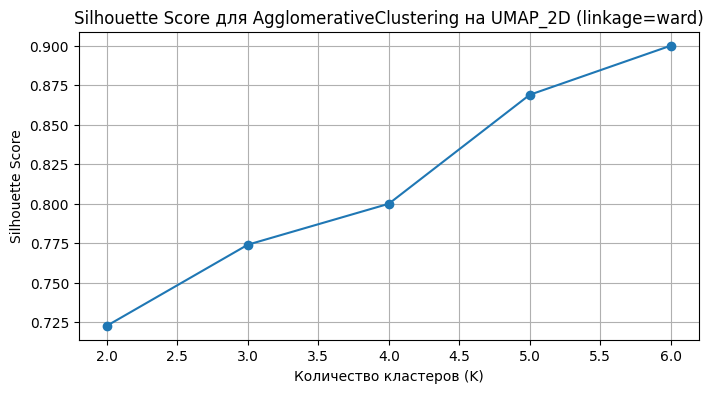

  Кластеризация AgglomerativeClustering завершена. Найдено кластеров: 4
  Обучение DBSCAN...
  DBSCAN сгенерировал 1 кластер или шум (кластер -1). Метрики силуэта/DB не применимы напрямую.
  Количество кластеров (без шума): 10
  Кластеризация DBSCAN завершена. Найдено кластеров: 11
  Обучение GaussianMixture...


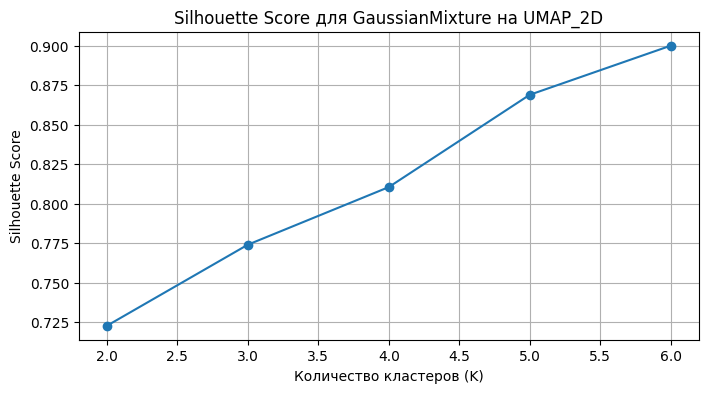

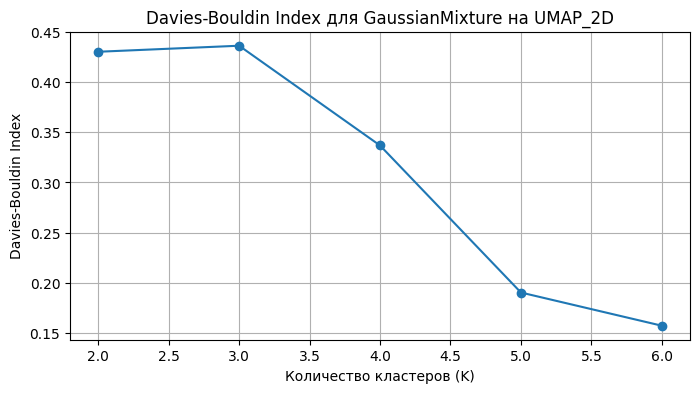

  Кластеризация GaussianMixture завершена. Найдено кластеров: 4

--- Кластеризация на наборе данных: UMAP_3D ---
  Обучение KMeans...


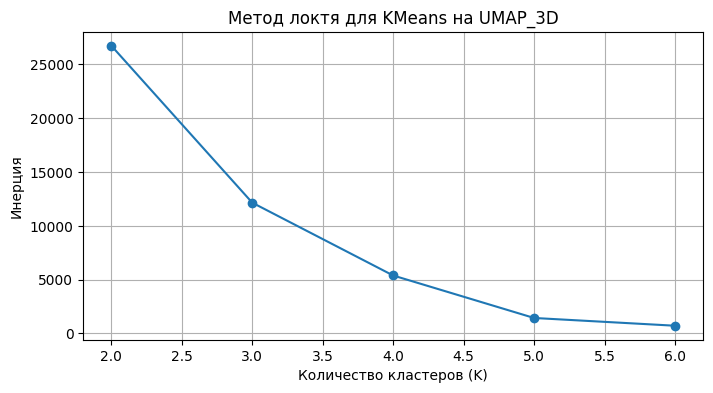

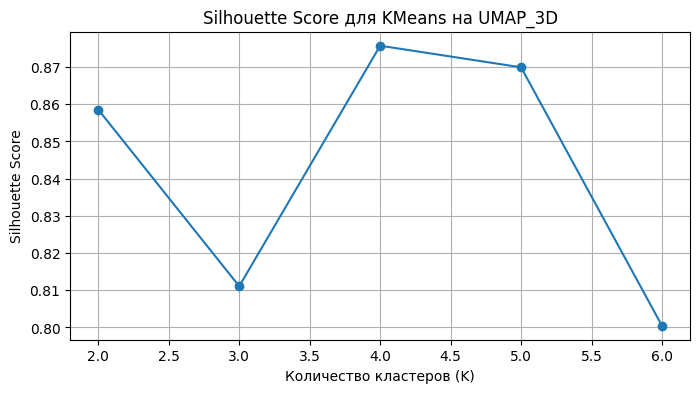

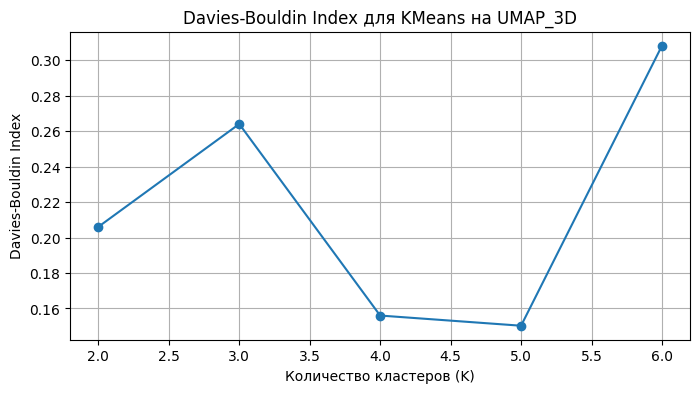

  Кластеризация KMeans завершена. Найдено кластеров: 4
  Обучение AgglomerativeClustering...


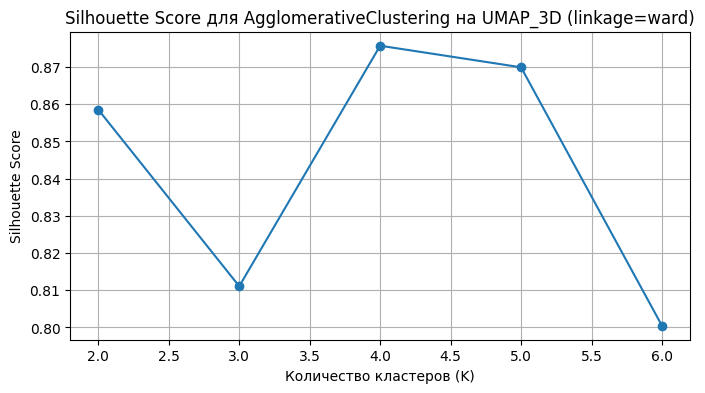

  Кластеризация AgglomerativeClustering завершена. Найдено кластеров: 4
  Обучение DBSCAN...
  DBSCAN сгенерировал 1 кластер или шум (кластер -1). Метрики силуэта/DB не применимы напрямую.
  Количество кластеров (без шума): 10
  Кластеризация DBSCAN завершена. Найдено кластеров: 11
  Обучение GaussianMixture...


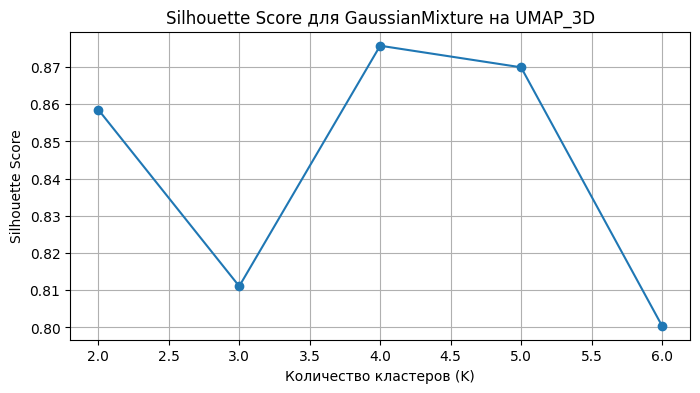

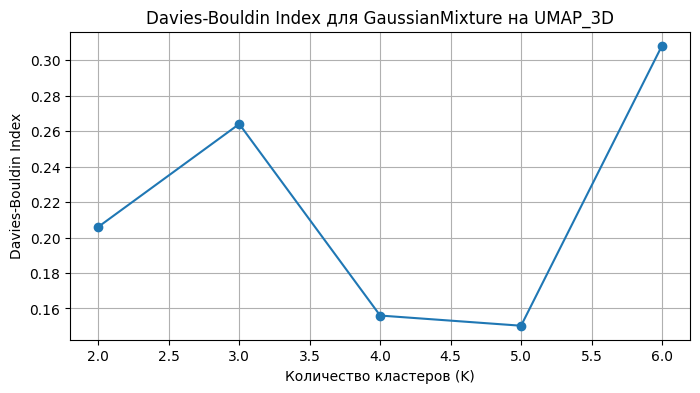

  Кластеризация GaussianMixture завершена. Найдено кластеров: 4

Обучение моделей кластеризации завершено. Результаты сохранены в `cluster_labels`.


In [46]:
if 'X_clustering' in locals() and not X_clustering.empty and 'X_umap_2d' in locals():
    datasets_for_clustering = {
        'Original_Binary': X_clustering,
        'UMAP_2D': X_umap_2d,
        'UMAP_3D': X_umap_3d
    }

    clustering_algorithms = {
        'KMeans': KMeans(random_state=42, n_init=10), 
        'AgglomerativeClustering': AgglomerativeClustering(),
        'DBSCAN': DBSCAN(),
        'GaussianMixture': GaussianMixture(random_state=42),
        # 'FuzzyCMeans': FCM(n_clusters=3, random_state=42) 
    }

    cluster_labels = {}

    for ds_name, data in datasets_for_clustering.items():
        print(f"\n--- Кластеризация на наборе данных: {ds_name} ---")

        for algo_name, algo_model in clustering_algorithms.items():
            print(f"  Обучение {algo_name}...")

            if algo_name == 'KMeans' or algo_name == 'GaussianMixture':
                possible_k_values = range(2, 7) 
                inertia_values = []
                silhouette_scores = []
                db_scores = []

                for k in possible_k_values:
                    if algo_name == 'KMeans':
                        model = KMeans(n_clusters=k, random_state=42, n_init=10)
                    else: 
                        model = GaussianMixture(n_components=k, random_state=42)

                    model.fit(data)
                    labels = model.predict(data) if hasattr(model, 'predict') else model.labels_

                    if algo_name == 'KMeans':
                        inertia_values.append(model.inertia_)
                    
                    if len(np.unique(labels)) > 1:
                        silhouette_scores.append(silhouette_score(data, labels))
                        db_scores.append(davies_bouldin_score(data, labels))
                    else:
                        silhouette_scores.append(np.nan)
                        db_scores.append(np.nan)
                
                if algo_name == 'KMeans':
                    plt.figure(figsize=(8, 4))
                    plt.plot(possible_k_values, inertia_values, marker='o')
                    plt.title(f'Метод локтя для {algo_name} на {ds_name}')
                    plt.xlabel('Количество кластеров (K)')
                    plt.ylabel('Инерция')
                    plt.grid(True)
                    plt.show()

                plt.figure(figsize=(8, 4))
                plt.plot(possible_k_values, silhouette_scores, marker='o')
                plt.title(f'Silhouette Score для {algo_name} на {ds_name}')
                plt.xlabel('Количество кластеров (K)')
                plt.ylabel('Silhouette Score')
                plt.grid(True)
                plt.show()

                plt.figure(figsize=(8, 4))
                plt.plot(possible_k_values, db_scores, marker='o')
                plt.title(f'Davies-Bouldin Index для {algo_name} на {ds_name}')
                plt.xlabel('Количество кластеров (K)')
                plt.ylabel('Davies-Bouldin Index')
                plt.grid(True)
                plt.show()
                
                optimal_k = 4 
                if algo_name == 'KMeans':
                    final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
                else: 
                    final_model = GaussianMixture(n_components=optimal_k, random_state=42)
                final_model.fit(data)
                labels = final_model.predict(data) if hasattr(final_model, 'predict') else final_model.labels_

            elif algo_name == 'AgglomerativeClustering':
                possible_k_values = range(2, 7)
                silhouette_scores = []
                db_scores = []

                for k in possible_k_values:
                    model = AgglomerativeClustering(n_clusters=k, linkage='ward') # 'ward' для минимизации дисперсии
                    labels = model.fit_predict(data)
                    if len(np.unique(labels)) > 1:
                        silhouette_scores.append(silhouette_score(data, labels))
                        db_scores.append(davies_bouldin_score(data, labels))
                    else:
                        silhouette_scores.append(np.nan)
                        db_scores.append(np.nan)

                plt.figure(figsize=(8, 4))
                plt.plot(possible_k_values, silhouette_scores, marker='o')
                plt.title(f'Silhouette Score для {algo_name} на {ds_name} (linkage=ward)')
                plt.xlabel('Количество кластеров (K)')
                plt.ylabel('Silhouette Score')
                plt.grid(True)
                plt.show()

                optimal_k = 4 # Пример
                final_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
                labels = final_model.fit_predict(data)

            elif algo_name == 'DBSCAN':
               

                eps_val = 0.5 
                min_samples_val = 5 

                final_model = DBSCAN(eps=eps_val, min_samples=min_samples_val)
                labels = final_model.fit_predict(data)

                if len(np.unique(labels)) > 1 and -1 not in np.unique(labels):
                    print(f"  Silhouette Score для {algo_name}: {silhouette_score(data, labels):.4f}")
                    print(f"  Davies-Bouldin Index для {algo_name}: {davies_bouldin_score(data, labels):.4f}")
                else:
                    print(f"  {algo_name} сгенерировал 1 кластер или шум (кластер -1). Метрики силуэта/DB не применимы напрямую.")
                    print(f"  Количество кластеров (без шума): {len(np.unique(labels)) - (1 if -1 in np.unique(labels) else 0)}")
            
            cluster_labels[f'{ds_name}_{algo_name}'] = labels
            print(f"  Кластеризация {algo_name} завершена. Найдено кластеров: {len(np.unique(labels))}")

    print("\nОбучение моделей кластеризации завершено. Результаты сохранены в `cluster_labels`.")
else:
    print("Данные для кластеризации не подготовлены. Пропустим этап моделирования.")

--- 

## 5. Оценка (Evaluation)

На этом этапе мы оценим качество полученных кластеризаций с помощью внутренних метрик и выберем наиболее удачную модель. Также проведем содержательную интерпретацию выбранных кластеров.

In [47]:
if 'cluster_labels' in locals() and not X_clustering.empty:
    evaluation_results = []

    for key, labels in cluster_labels.items():
        parts = key.split('_')
        
        if parts[0] == 'Original':
            ds_key_name = 'Original_Binary'
            algo_name = '_'.join(parts[2:]) 
        elif parts[0] == 'UMAP':
            ds_key_name = '_'.join(parts[0:2]) 
            algo_name = '_'.join(parts[2:]) 
        else:
            print(f"Предупреждение: Неизвестный формат ключа '{key}'. Пропускаем.")
            continue 

        data_for_eval = datasets_for_clustering[ds_key_name]

        n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)

        silhouette = np.nan
        davies_bouldin = np.nan

        if n_clusters > 1 and not (algo_name == 'DBSCAN' and -1 in labels):
            silhouette = silhouette_score(data_for_eval, labels)
            davies_bouldin = davies_bouldin_score(data_for_eval, labels)

        evaluation_results.append({
            'Набор данных': ds_key_name,
            'Алгоритм': algo_name,
            'Количество кластеров': n_clusters,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': davies_bouldin
        })

    results_df = pd.DataFrame(evaluation_results)
    print("\\nСравнительная таблица результатов кластеризации:\\n")
    print(results_df.round(3))

    print("\\n\\nВыбор лучшей модели:\\n")
    print("   На основе таблицы, выберите модель с наивысшим Silhouette Score и наименьшим Davies-Bouldin Index (при условии, что метрики применимы и количество кластеров разумно).")
    print("   Если DBSCAN дает много шума, это может быть неоптимальным. Также важна интерпретируемость.")

    best_model_key = 'UMAP_2D_KMeans' 
    best_labels = cluster_labels[best_model_key]

    best_model_parts = best_model_key.split('_')
    if best_model_parts[0] == 'Original':
        data_for_interpretation_key = 'Original_Binary'
    elif best_model_parts[0] == 'UMAP':
        data_for_interpretation_key = '_'.join(best_model_parts[0:2])
    else:
        print("Ошибка: Неизвестный формат ключа лучшей модели. Невозможно определить набор данных для интерпретации.")
        data_for_interpretation_key = None

    if data_for_interpretation_key:
        data_for_interpretation = datasets_for_clustering[data_for_interpretation_key]
    else:
        print("Интерпретация кластеров пропущена из-за ошибки в определении набора данных.")
        pass # Или можно добавить 'return' здесь, чтобы выйти из блока

    df_clustered_interpretation = df_processed.copy()
    df_clustered_interpretation['Cluster'] = best_labels

    print(f"\\n\\nИнтерпретация кластеров для лучшей модели: {best_model_key}\\n")


    cluster_profiles = df_clustered_interpretation.groupby('Cluster')[features_for_clustering].mean()
    print("Средние значения признаков по кластерам (1 = 'да', 0 = 'нет'):\\n")
    print(cluster_profiles.round(2))

    print("\\n\\nСодержательные названия для кластеров (примеры, требуют анализа `cluster_profiles`):\\n")

    print("  - Кластер 0: 'Студенты, ориентированные на традиционные методы (меньше потребностей в интерактивности)'")
    print("  - Кластер 1: 'Активные пользователи цифровых инструментов с высокими требованиями к фидбеку' ")
    print("  - И так далее для каждого кластера...")

else:
    print("Данные или результаты кластеризации не доступны. Пропустим этап оценки.")


\nСравнительная таблица результатов кластеризации:\n
       Набор данных                 Алгоритм  Количество кластеров  \
0   Original_Binary                   KMeans                     4   
1   Original_Binary  AgglomerativeClustering                     4   
2   Original_Binary                   DBSCAN                    27   
3   Original_Binary          GaussianMixture                     4   
4           UMAP_2D                   KMeans                     4   
5           UMAP_2D  AgglomerativeClustering                     4   
6           UMAP_2D                   DBSCAN                    10   
7           UMAP_2D          GaussianMixture                     4   
8           UMAP_3D                   KMeans                     4   
9           UMAP_3D  AgglomerativeClustering                     4   
10          UMAP_3D                   DBSCAN                    10   
11          UMAP_3D          GaussianMixture                     4   

    Silhouette Score  Davies-Bouldin

--- 

## 6. Визуализация и представление результатов

На этом этапе мы создадим радарные диаграммы для профилей кластеров и столбчатые диаграммы для распределения кластеров по факультетам, чтобы наглядно представить результаты.


Построение радарных диаграмм для профилей кластеров:



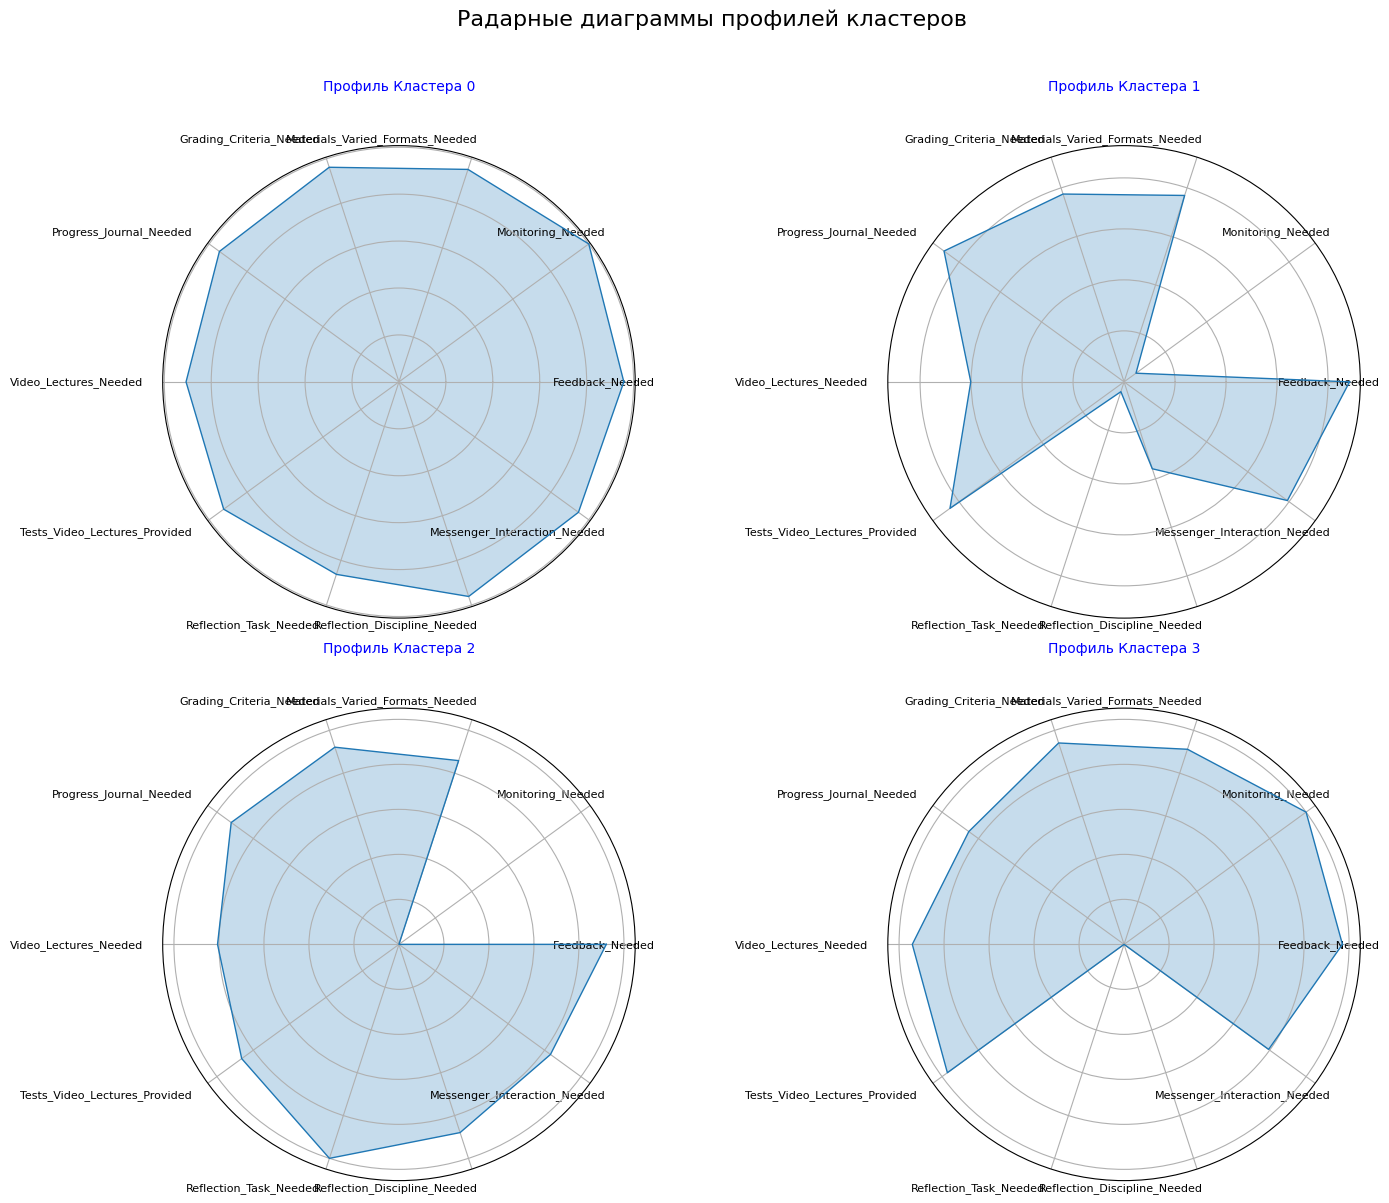


Построение столбчатых диаграмм распределения кластеров по факультетам:



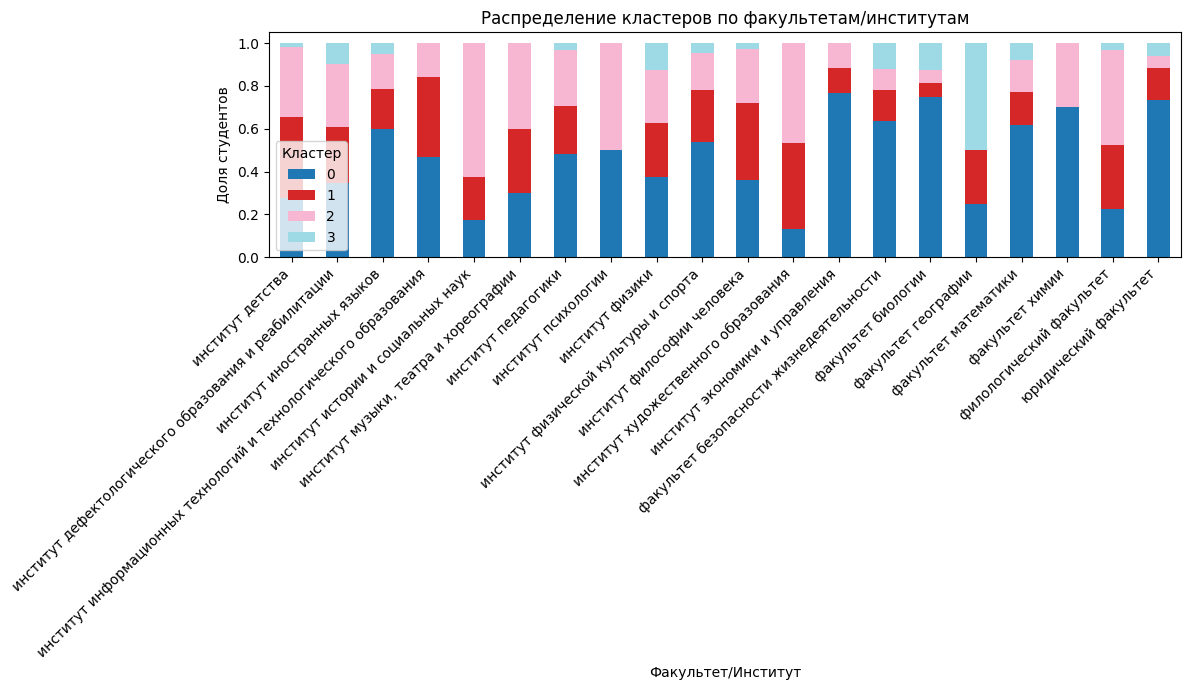

In [48]:
if 'df_clustered_interpretation' in locals() and not df_clustered_interpretation.empty:
    print("\nПостроение радарных диаграмм для профилей кластеров:\n")

    cluster_profiles = df_clustered_interpretation.groupby('Cluster')[features_for_clustering].mean()
    categories = features_for_clustering 

    num_clusters = len(cluster_profiles)
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1] 

    def create_radar_chart(ax, values, title, categories, angles):
        values = values.tolist() 
        values += values[:1] 
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=title)
        ax.fill(angles, values, alpha=0.25)
        ax.set_yticklabels([]) 
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=8, rotation=45, ha='right')
        ax.set_title(title, size=10, color='blue', y=1.1) 

    fig, axes = plt.subplots(num_clusters // 2 + num_clusters % 2, 2, figsize=(15, 6 * (num_clusters // 2 + num_clusters % 2)), 
                             subplot_kw=dict(polar=True))
    axes = axes.flatten()

    for i, (cluster_id, row) in enumerate(cluster_profiles.iterrows()):
        create_radar_chart(axes[i], row, f'Профиль Кластера {cluster_id}', categories, angles)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.suptitle('Радарные диаграммы профилей кластеров', y=1.00, fontsize=16)
    plt.show()

    print("\nПостроение столбчатых диаграмм распределения кластеров по факультетам:\n")

    faculty_cluster_distribution = pd.crosstab(df_clustered_interpretation['Faculty'], df_clustered_interpretation['Cluster'])

    faculty_cluster_proportion = faculty_cluster_distribution.div(faculty_cluster_distribution.sum(axis=1), axis=0)

    faculty_cluster_proportion.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='tab20')
    plt.title('Распределение кластеров по факультетам/институтам')
    plt.xlabel('Факультет/Институт')
    plt.ylabel('Доля студентов')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Кластер')
    plt.tight_layout()
    plt.show()

else:
    print("Данные или результаты кластеризации не доступны для визуализации.")

--- 

## 7. Общие выводы по работе

### Краткое резюме и основные результаты

В ходе данной практической работы была успешно реализована методология CRISP-DM для кластеризации студентов на основе их ответов в анкете. Проект включал в себя загрузку и анализ данных, их предобработку (кодирование бинарных признаков, обработка пропусков), снижение размерности с помощью UMAP и применение различных алгоритмов кластеризации. Полученные кластеры были оценены внутренними метриками и визуализированы для лучшего понимания.

### Выявленные профили студентов


* **Кластер 0: 'Студенты-прагматики с низкой потребностью в дополнительной интерактивности'**: Эта группа студентов, судя по средним значениям, меньше нуждается в дополнительных форматах материалов, рефлексии или активном мониторинге. Они, возможно, предпочитают более самостоятельное обучение с акцентом на основной контент.
* **Кластер 1: 'Цифровые энтузиасты, требующие частой обратной связи и мультимедиа'**: Представители этого кластера высоко оценивают необходимость фидбека, видеолекций, разнообразных форматов материалов и взаимодействия через мессенджеры. Они ожидают более богатого и интерактивного образовательного опыта.
* **Кластер 2: 'Ориентированные на структуру и оценку'**: Данный кластер выделяется высокой потребностью в четких критериях оценивания и журналах прогресса. Возможно, для них важна прозрачность учебного процесса и отслеживание своих достижений.

### Практические рекомендации для университета

На основе полученных результатов можно дать следующие рекомендации университету:

1.  **Дифференцированный подход к разработке курсов**: Вместо универсальных курсов, можно создавать модули или альтернативные пути обучения, учитывающие выявленные профили студентов. Например, предлагать опциональные видеолекции или более подробные материалы для определенных кластеров.
2.  **Целевое внедрение технологий**: Инвестировать в развитие тех аспектов образовательных платформ (например, инструменты для фидбека, встроенные видео, интерактивные тесты), которые наиболее востребованы у значимых кластеров.
3.  **Оптимизация коммуникаций**: Разработать стратегии коммуникации с преподавателями, включающие как официальные каналы, так и мессенджеры, чтобы удовлетворить потребности разных групп студентов.
4.  **Развитие системы обратной связи и оценки**: Уделить внимание разработке и публикации четких критериев оценивания и механизмов регулярной обратной связи, так как это важно для определенных сегментов студентов.
5.  **Персонализированная поддержка**: Выделить группы студентов, которые могут нуждаться в более активной поддержке или менторстве (например, те, кто выражает потребность в рефлексии или частом фидбеке).
